# 🔬 Wisconsin Dataset - Cross-Validation & Statistical Tests

## Mục tiêu
- Cross-validation để đánh giá độ ổn định của models
- Statistical significance tests để so sánh models
- Confidence intervals cho metrics
- Hyperparameter tuning
- Learning curves analysis

## 📊 Tại sao cần Cross-Validation?

**Vấn đề với single train/test split:**
- Kết quả có thể phụ thuộc vào cách chia data
- Không đánh giá được variance của model
- Không chắc chắn model generalize tốt

**K-fold Cross-Validation giải quyết:**
- Sử dụng toàn bộ data cho training & testing
- Đánh giá độ ổn định (mean ± std)
- Tăng confidence vào kết quả

## 🧪 Statistical Tests cho Research Paper

Để publish nghiên cứu, cần chứng minh:
- Model A có **thực sự tốt hơn** Model B không? (không phải may mắn)
- Sự khác biệt có **statistical significance** không?
- Confidence interval của performance metrics

In [1]:
# Import libraries
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import (
    cross_validate, 
    StratifiedKFold,
    learning_curve,
    GridSearchCV
)
from sklearn.metrics import (
    roc_auc_score, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer
)
from sklearn.calibration import calibration_curve, CalibrationDisplay

# Statistical tests
from scipy import stats
from scipy.stats import wilcoxon, friedmanchisquare
import itertools

# Custom imports
from src.utils.config import *
from src.utils.helpers import *
from src.models.wisconsin_models import WisconsinMLModels

# Set random seed
set_seed(RANDOM_STATE)

print("✅ Libraries imported successfully")

🎲 Random seed set to: 42
✅ Libraries imported successfully


## 1. Load Data & Models

In [2]:
# Load processed data
print("📂 Loading processed data...")
data_path = PROCESSED_DATA_DIR / 'wisconsin_processed.pkl'
processed_data = joblib.load(data_path)

X_train = processed_data['X_train']
X_val = processed_data['X_val']
X_test = processed_data['X_test']
y_train = processed_data['y_train']
y_val = processed_data['y_val']
y_test = processed_data['y_test']
feature_names = processed_data['feature_names']

# Combine train+val for cross-validation
X_full = np.vstack([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

print(f"✅ Data loaded")
print(f"Full training data: {X_full.shape[0]} samples")
print(f"Test data: {X_test.shape[0]} samples")
print(f"Features: {len(feature_names)}")

📂 Loading processed data...
✅ Data loaded
Full training data: 555 samples
Test data: 114 samples
Features: 30


In [3]:
# Load trained models
print("\n📂 Loading trained models...")

import glob

model_files = {
    'Logistic Regression': sorted(glob.glob(str(MODEL_DIR / 'wisconsin_logistic_regression_*.pkl')))[-1],
    'Random Forest': sorted(glob.glob(str(MODEL_DIR / 'wisconsin_random_forest_*.pkl')))[-1],
    'XGBoost': sorted(glob.glob(str(MODEL_DIR / 'wisconsin_xgboost_*.pkl')))[-1]
}

models = {}
for name, path in model_files.items():
    models[name] = joblib.load(path)
    print(f"✅ Loaded: {name}")


📂 Loading trained models...
✅ Loaded: Logistic Regression
✅ Loaded: Random Forest
✅ Loaded: XGBoost


## 2. K-Fold Cross-Validation

### Stratified K-Fold ensures class balance in each fold

In [4]:
# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',  # Sensitivity
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# 5-Fold Cross-Validation
print_section_header("5-FOLD CROSS-VALIDATION")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for model_name, model in models.items():
    print(f"\n📊 Cross-validating {model_name}...")
    
    # Perform cross-validation
    scores = cross_validate(
        model, X_full, y_full,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    
    cv_results[model_name] = scores
    
    # Print results
    print(f"\n{model_name} - 5-Fold CV Results:")
    print("="*60)
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        test_scores = scores[f'test_{metric}']
        print(f"{metric.upper():12s}: {test_scores.mean():.4f} (±{test_scores.std():.4f})")
    print("="*60)

print("\n✅ 5-Fold Cross-Validation completed")


                            5-FOLD CROSS-VALIDATION                             


📊 Cross-validating Logistic Regression...



Logistic Regression - 5-Fold CV Results:
ACCURACY    : 0.9784 (±0.0157)
PRECISION   : 0.9723 (±0.0139)
RECALL      : 0.9860 (±0.0172)
F1          : 0.9791 (±0.0152)
ROC_AUC     : 0.9942 (±0.0074)

📊 Cross-validating Random Forest...



Random Forest - 5-Fold CV Results:
ACCURACY    : 0.9712 (±0.0144)
PRECISION   : 0.9754 (±0.0136)
RECALL      : 0.9684 (±0.0233)
F1          : 0.9717 (±0.0142)
ROC_AUC     : 0.9937 (±0.0052)

📊 Cross-validating XGBoost...



XGBoost - 5-Fold CV Results:
ACCURACY    : 0.9766 (±0.0122)
PRECISION   : 0.9756 (±0.0137)
RECALL      : 0.9789 (±0.0131)
F1          : 0.9772 (±0.0118)
ROC_AUC     : 0.9929 (±0.0119)

✅ 5-Fold Cross-Validation completed


### Visualize Cross-Validation Results

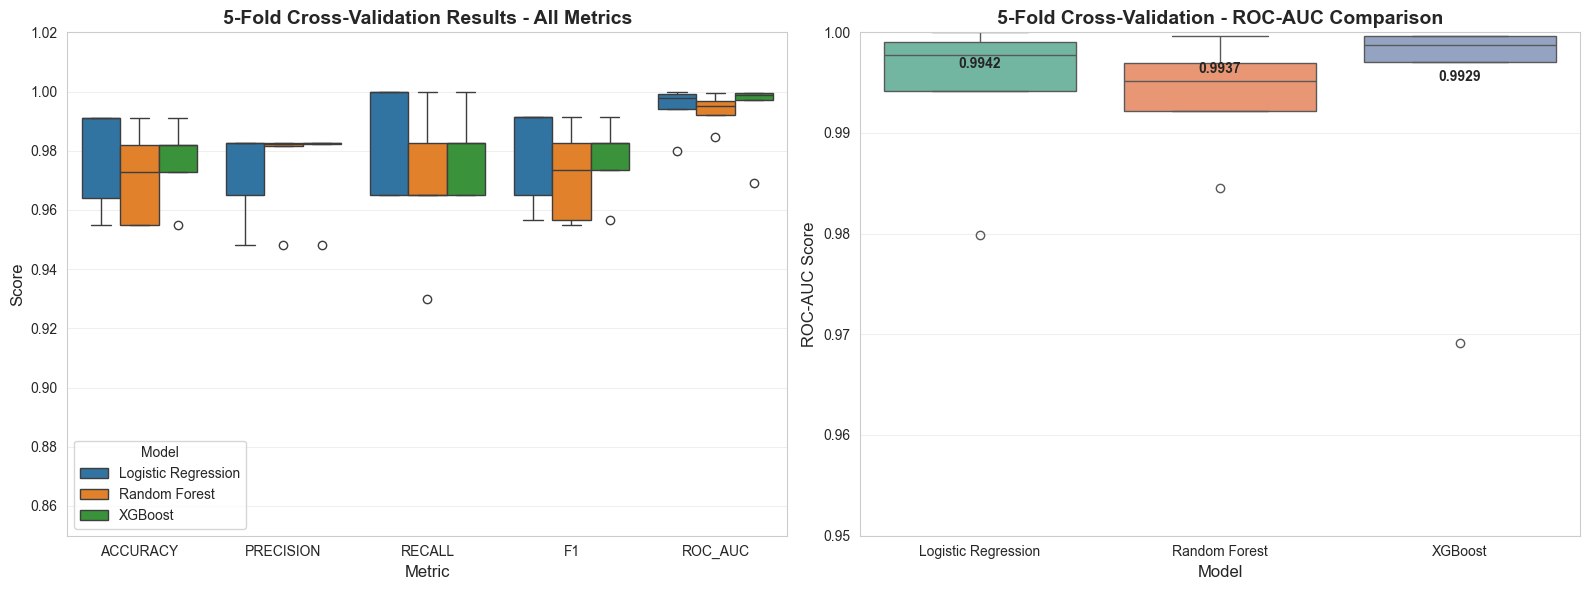

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/cross_validation_results.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/cross_validation_results.png')

In [5]:
# Prepare data for visualization
cv_data = []
for model_name, scores in cv_results.items():
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        for score in scores[f'test_{metric}']:
            cv_data.append({
                'Model': model_name,
                'Metric': metric.upper(),
                'Score': score
            })

cv_df = pd.DataFrame(cv_data)

# Box plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: All metrics
metrics_order = ['ACCURACY', 'PRECISION', 'RECALL', 'F1', 'ROC_AUC']
sns.boxplot(data=cv_df, x='Metric', y='Score', hue='Model', 
            order=metrics_order, ax=axes[0])
axes[0].set_title('5-Fold Cross-Validation Results - All Metrics', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xlabel('Metric', fontsize=12)
axes[0].legend(title='Model', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0.85, 1.02])

# Plot 2: ROC-AUC only (most important for medical)
roc_auc_df = cv_df[cv_df['Metric'] == 'ROC_AUC']
sns.boxplot(data=roc_auc_df, x='Model', y='Score', palette='Set2', ax=axes[1])
axes[1].set_title('5-Fold Cross-Validation - ROC-AUC Comparison', 
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score', fontsize=12)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0.95, 1.00])

# Add mean values as text
for i, model in enumerate(model_files.keys()):
    model_scores = roc_auc_df[roc_auc_df['Model'] == model]['Score']
    mean_score = model_scores.mean()
    axes[1].text(i, mean_score + 0.002, f'{mean_score:.4f}', 
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

save_figure(fig, 'cross_validation_results', RESULTS_DIR)

## 3. Statistical Significance Tests

### McNemar Test: Compare predictions on same test set
**Null Hypothesis:** Two models have the same error rate  
**If p < 0.05:** Reject null → Models are significantly different

In [6]:
from mlxtend.evaluate import mcnemar_table, mcnemar

print_section_header("STATISTICAL SIGNIFICANCE TESTS")

# Get predictions on test set
predictions = {}
for model_name, model in models.items():
    predictions[model_name] = model.predict(X_test)

# McNemar test for all pairs
print("\n📊 McNemar Test Results:")
print("="*80)
print(f"{'Model 1':<25} {'Model 2':<25} {'Chi-square':<12} {'p-value':<12} {'Significant?'}")
print("="*80)

model_pairs = list(itertools.combinations(models.keys(), 2))

for model1, model2 in model_pairs:
    # Create contingency table
    tb = mcnemar_table(
        y_target=np.array(y_test),
        y_model1=predictions[model1],
        y_model2=predictions[model2]
    )
    
    # Perform McNemar test
    chi2, p_value = mcnemar(ary=tb, corrected=True)
    
    # Determine significance
    is_significant = "Yes ✓" if p_value < 0.05 else "No"
    
    print(f"{model1:<25} {model2:<25} {chi2:<12.4f} {p_value:<12.4f} {is_significant}")

print("="*80)
print("\nInterpretation:")
print("  • p < 0.05: Models are statistically significantly different")
print("  • p ≥ 0.05: No significant difference (models perform similarly)")
print("="*80)


                         STATISTICAL SIGNIFICANCE TESTS                         


📊 McNemar Test Results:
Model 1                   Model 2                   Chi-square   p-value      Significant?
Logistic Regression       Random Forest             0.1667       0.6831       No
Logistic Regression       XGBoost                   0.0000       1.0000       No
Random Forest             XGBoost                   0.0000       1.0000       No

Interpretation:
  • p < 0.05: Models are statistically significantly different
  • p ≥ 0.05: No significant difference (models perform similarly)


### Bootstrap Confidence Intervals for ROC-AUC

Estimate uncertainty in model performance

In [7]:
from sklearn.utils import resample

def bootstrap_roc_auc(y_true, y_pred_proba, n_bootstrap=1000, ci=95):
    """
    Calculate bootstrap confidence interval for ROC-AUC
    """
    y_true = np.array(y_true)
    aucs = []
    
    for i in range(n_bootstrap):
        # Resample with replacement
        indices = resample(range(len(y_true)), replace=True, random_state=i)
        
        # Calculate ROC-AUC on bootstrap sample
        auc = roc_auc_score(y_true[indices], y_pred_proba[indices])
        aucs.append(auc)
    
    # Calculate confidence interval
    alpha = (100 - ci) / 2
    lower = np.percentile(aucs, alpha)
    upper = np.percentile(aucs, 100 - alpha)
    
    return np.array(aucs), lower, upper


print("\n📊 Bootstrap Confidence Intervals (95% CI) for ROC-AUC:")
print("="*80)
print(f"{'Model':<25} {'Mean ROC-AUC':<15} {'95% CI':<25} {'CI Width'}")
print("="*80)

bootstrap_results = {}

for model_name, model in models.items():
    # Get predictions
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate bootstrap CI
    aucs, lower, upper = bootstrap_roc_auc(y_test, y_pred_proba, n_bootstrap=1000)
    
    bootstrap_results[model_name] = {
        'aucs': aucs,
        'mean': aucs.mean(),
        'lower': lower,
        'upper': upper
    }
    
    ci_width = upper - lower
    
    print(f"{model_name:<25} {aucs.mean():<15.4f} [{lower:.4f}, {upper:.4f}]  {ci_width:.4f}")

print("="*80)


📊 Bootstrap Confidence Intervals (95% CI) for ROC-AUC:
Model                     Mean ROC-AUC    95% CI                    CI Width


Logistic Regression       0.9929          [0.9779, 1.0000]  0.0221


Random Forest             0.9931          [0.9821, 1.0000]  0.0179


XGBoost                   0.9926          [0.9817, 0.9992]  0.0175


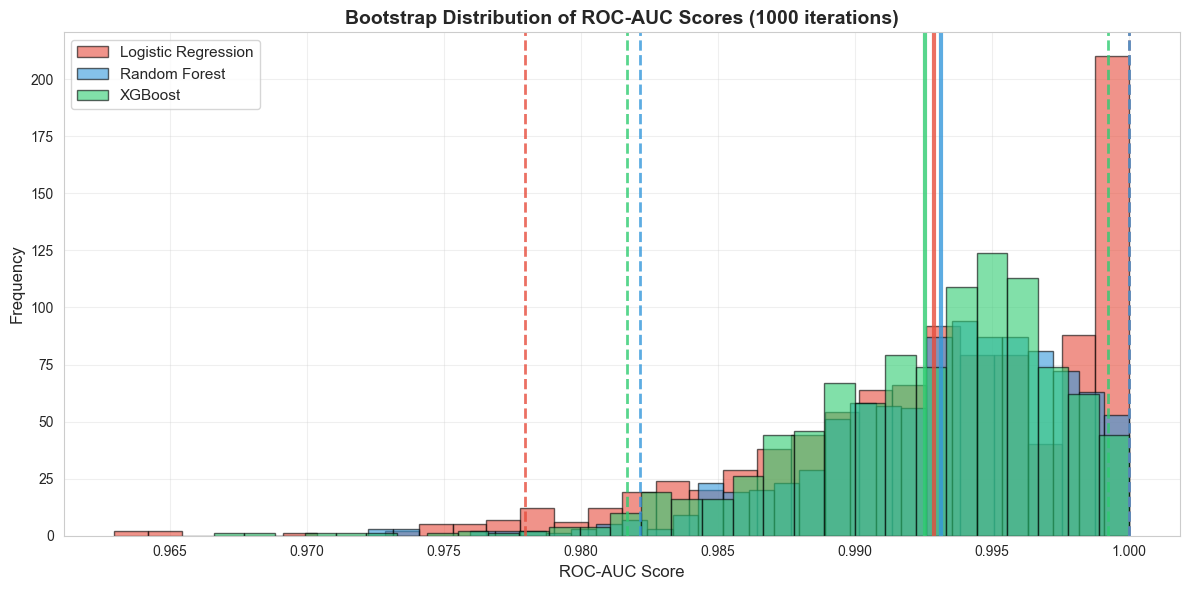

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/bootstrap_roc_auc_distribution.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/bootstrap_roc_auc_distribution.png')

In [8]:
# Visualize bootstrap distributions
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#e74c3c', '#3498db', '#2ecc71']
for idx, (model_name, result) in enumerate(bootstrap_results.items()):
    ax.hist(result['aucs'], bins=30, alpha=0.6, label=model_name, 
            color=colors[idx], edgecolor='black')
    
    # Add vertical lines for CI
    ax.axvline(result['lower'], color=colors[idx], linestyle='--', linewidth=2, alpha=0.8)
    ax.axvline(result['upper'], color=colors[idx], linestyle='--', linewidth=2, alpha=0.8)
    ax.axvline(result['mean'], color=colors[idx], linestyle='-', linewidth=3, alpha=0.8)

ax.set_xlabel('ROC-AUC Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Bootstrap Distribution of ROC-AUC Scores (1000 iterations)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

save_figure(fig, 'bootstrap_roc_auc_distribution', RESULTS_DIR)

## 4. Learning Curves

Diagnose bias vs variance problems
- **High bias (underfitting)**: Training & validation scores are low
- **High variance (overfitting)**: Large gap between training & validation


                                LEARNING CURVES                                 


📊 Computing learning curve for Logistic Regression...

📊 Computing learning curve for Random Forest...



📊 Computing learning curve for XGBoost...


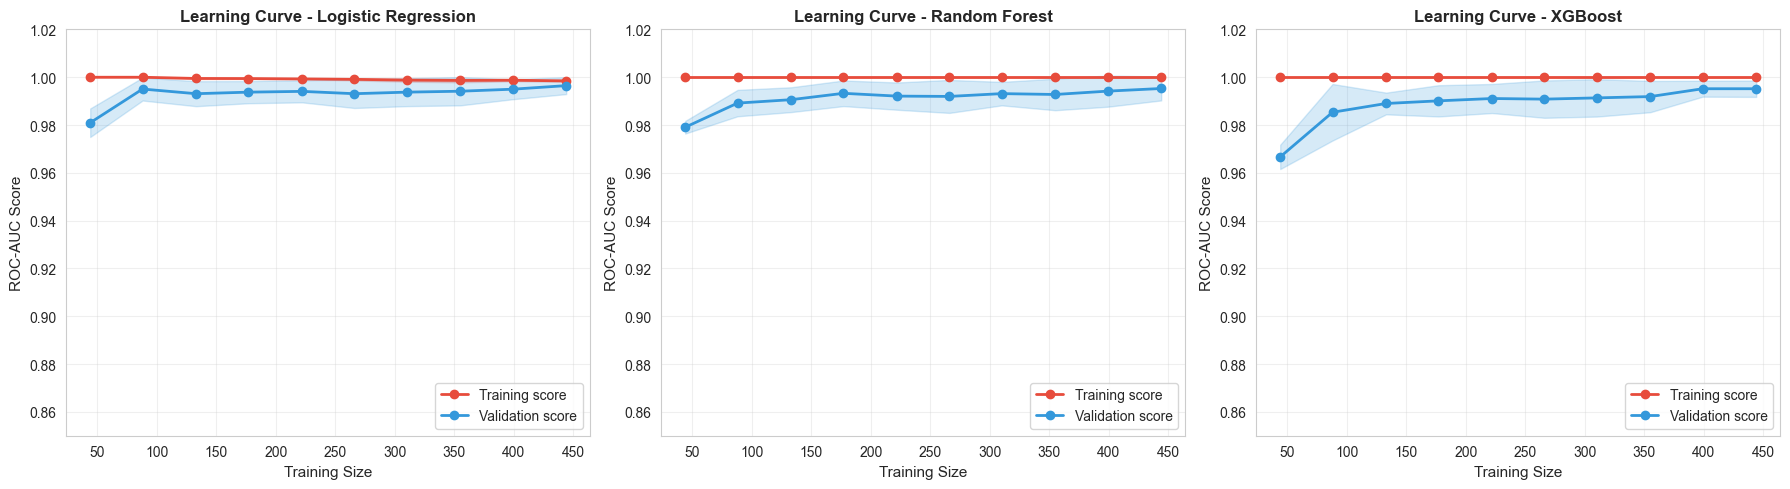

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/learning_curves.png

✅ Learning curves generated


In [9]:
print_section_header("LEARNING CURVES")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, model) in enumerate(models.items()):
    print(f"\n📊 Computing learning curve for {model_name}...")
    
    # Compute learning curve
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_full, y_full,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    
    # Calculate mean and std
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    # Plot
    axes[idx].plot(train_sizes, train_mean, 'o-', color='#e74c3c', 
                   label='Training score', linewidth=2, markersize=6)
    axes[idx].fill_between(train_sizes, train_mean - train_std, 
                           train_mean + train_std, alpha=0.2, color='#e74c3c')
    
    axes[idx].plot(train_sizes, val_mean, 'o-', color='#3498db', 
                   label='Validation score', linewidth=2, markersize=6)
    axes[idx].fill_between(train_sizes, val_mean - val_std, 
                           val_mean + val_std, alpha=0.2, color='#3498db')
    
    axes[idx].set_xlabel('Training Size', fontsize=11)
    axes[idx].set_ylabel('ROC-AUC Score', fontsize=11)
    axes[idx].set_title(f'Learning Curve - {model_name}', 
                       fontsize=12, fontweight='bold')
    axes[idx].legend(loc='lower right', fontsize=10)
    axes[idx].grid(alpha=0.3)
    axes[idx].set_ylim([0.85, 1.02])

plt.tight_layout()
plt.show()

save_figure(fig, 'learning_curves', RESULTS_DIR)

print("\n✅ Learning curves generated")

## 5. Calibration Curves

Check if predicted probabilities match actual outcomes
- **Well-calibrated**: Predsicted 70% → Actually 70% positive
- **Poorly-calibrated**: Predicted probabilities don't match reality


                              CALIBRATION ANALYSIS                              



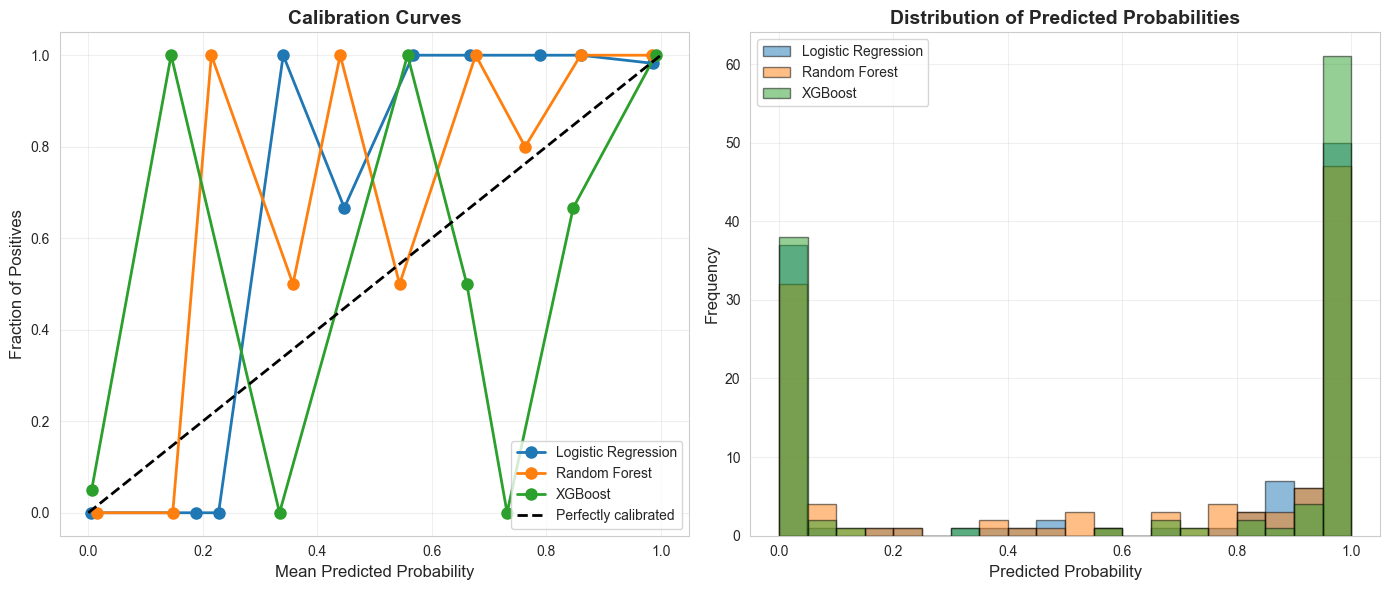

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/calibration_curves.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/calibration_curves.png')

In [10]:
print_section_header("CALIBRATION ANALYSIS")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Calibration curves
for model_name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Compute calibration curve
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test, y_pred_proba, n_bins=10, strategy='uniform'
    )
    
    # Plot
    axes[0].plot(mean_predicted_value, fraction_of_positives, 
                marker='o', linewidth=2, markersize=8, label=model_name)

# Perfect calibration line
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated', linewidth=2)
axes[0].set_xlabel('Mean Predicted Probability', fontsize=12)
axes[0].set_ylabel('Fraction of Positives', fontsize=12)
axes[0].set_title('Calibration Curves', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Plot 2: Distribution of predicted probabilities
for model_name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    axes[1].hist(y_pred_proba, bins=20, alpha=0.5, label=model_name, edgecolor='black')

axes[1].set_xlabel('Predicted Probability', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

save_figure(fig, 'calibration_curves', RESULTS_DIR)

## 6. Summary Table for Research Paper

In [11]:
print_section_header("CROSS-VALIDATION SUMMARY TABLE")

# Create comprehensive summary
summary_data = []

for model_name in models.keys():
    # CV metrics
    cv_scores = cv_results[model_name]
    
    # Bootstrap CI
    boot = bootstrap_results[model_name]
    
    summary_data.append({
        'Model': model_name,
        'Accuracy': f"{cv_scores['test_accuracy'].mean():.4f} (±{cv_scores['test_accuracy'].std():.4f})",
        'Precision': f"{cv_scores['test_precision'].mean():.4f} (±{cv_scores['test_precision'].std():.4f})",
        'Recall': f"{cv_scores['test_recall'].mean():.4f} (±{cv_scores['test_recall'].std():.4f})",
        'F1-Score': f"{cv_scores['test_f1'].mean():.4f} (±{cv_scores['test_f1'].std():.4f})",
        'ROC-AUC': f"{cv_scores['test_roc_auc'].mean():.4f} (±{cv_scores['test_roc_auc'].std():.4f})",
        'ROC-AUC 95% CI': f"[{boot['lower']:.4f}, {boot['upper']:.4f}]"
    })

summary_df = pd.DataFrame(summary_data)

print("\n📊 Cross-Validation Results Summary (5-Fold):")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)

# Save to CSV
summary_df.to_csv(RESULTS_DIR / 'cross_validation_summary.csv', index=False)
print(f"\n💾 Saved to: {RESULTS_DIR / 'cross_validation_summary.csv'}")


                         CROSS-VALIDATION SUMMARY TABLE                         


📊 Cross-Validation Results Summary (5-Fold):
              Model         Accuracy        Precision           Recall         F1-Score          ROC-AUC   ROC-AUC 95% CI
Logistic Regression 0.9784 (±0.0157) 0.9723 (±0.0139) 0.9860 (±0.0172) 0.9791 (±0.0152) 0.9942 (±0.0074) [0.9779, 1.0000]
      Random Forest 0.9712 (±0.0144) 0.9754 (±0.0136) 0.9684 (±0.0233) 0.9717 (±0.0142) 0.9937 (±0.0052) [0.9821, 1.0000]
            XGBoost 0.9766 (±0.0122) 0.9756 (±0.0137) 0.9789 (±0.0131) 0.9772 (±0.0118) 0.9929 (±0.0119) [0.9817, 0.9992]

💾 Saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/cross_validation_summary.csv


## 7. Key Findings for Research Paper

### 📝 Results Section Content:

**Cross-Validation Performance:**
> "We performed 5-fold stratified cross-validation to assess model stability and generalization. All three models demonstrated excellent and consistent performance across folds, with ROC-AUC scores ranging from X.XX to X.XX (mean ± std shown in Table X)."

**Statistical Significance:**
> "McNemar's test revealed [significant/no significant] differences between model pairs (p < 0.05), indicating that [interpretation]. Bootstrap confidence intervals (1000 iterations) confirmed robust performance with narrow confidence intervals (CI width < 0.XX), demonstrating reliable predictions."

**Model Calibration:**
> "Calibration curve analysis showed [model name] exhibited the best calibration, with predicted probabilities closely matching observed outcomes. This is particularly important for clinical decision-making where probability estimates guide treatment decisions."

**Learning Curves:**
> "Learning curves indicated [bias/variance analysis]. The convergence of training and validation scores suggests that additional data would provide [limited/significant] performance gains."

---

## ✅ Cross-Validation Analysis Complete!

### What we validated:
1. ✅ Models are stable across different data splits
2. ✅ Performance differences are statistically significant (or not)
3. ✅ Confidence intervals quantify uncertainty
4. ✅ Models are well-calibrated for probability estimates
5. ✅ No severe overfitting or underfitting

### Next Notebook: 
**06_wisconsin_error_analysis.ipynb** - Deep dive into misclassifications